# In this tutorial, we present some of the code used in the article entitled 'Entropy-based regularized regression for advanced distribution of relaxation times deconvolution' (DOI: j.jpowsour.2025.236910).

In [15]:
# import necessary packages
import numpy as np
import pandas as pd
from scipy.linalg import block_diag
import matplotlib.pyplot as plt
import cvxpy as cp
import os
from pathlib import Path
import re
from math import pi, sin, cos

# custom module import
import compute_DRT

In [16]:
# plot settings
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=15)
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)

# colors for the figures
CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

# 1. Load the experimental spectra

In [17]:
N_exp = 13
freq_list = [0]*N_exp
Z_re_list = [0]*N_exp
Z_im_list = [0]*N_exp

T_min = 1
T_max = 14
delta_T = 1
psi_list = np.arange(T_min, T_max, delta_T)

for n in range(N_exp):
    df = pd.read_csv('./EIS-data_solar-cells/0' + str(psi_list[n]) + '.csv')
    freq_list[n] = df['Freq'].to_numpy()
    Z_re_list[n] = df['Real'].to_numpy()
    Z_im_list[n] = df['Imag'].to_numpy()

# 2. Deconvolve the DRTs jointly

## 2.1 Define the functions

In [18]:
def prepare_matrices(freq_vec, log_tau_vec):
    """
    Prepares the A matrices for DRT inversion.

    Parameters:
    - freq_vec: array of frequencies
    - log_tau_vec: array of log(tau) values

    Returns:
    - A_i: prepared A matrix for the given frequency vector
    """
    N_freqs = len(freq_vec)
    A_complex = compute_DRT.compute_A_complex(freq_vec, log_tau_vec)
    A_re = np.real(A_complex)
    A_im = np.imag(A_complex)

    # Build A_R_infty and A_L
    A_R_infty = np.zeros((2 * N_freqs, 1))
    A_R_infty[:N_freqs, 0] = 1.0

    A_L = np.zeros((2 * N_freqs, 1))
    A_L[N_freqs:, 0] = 2.0 * pi * freq_vec  # Correct assignment

    # Combine to form A_i
    A_i = np.hstack((A_R_infty, A_L, np.vstack((A_re, A_im))))

    return A_i

def prob_entropy(lambda_0, A, Z):
    """
    Solves an optimization problem with entropy regularization.
    """
    N_fs = np.size(Z)//2
    x = cp.Variable(A.shape[1], nonneg=True)
    objective = cp.Minimize(cp.norm(A @ x - Z, p=2)**2-lambda_0 * cp.sum(cp.entr(x[2:])))
    prob = cp.Problem(objective)
    prob.solve(solver=cp.MOSEK)
    
    x_val = x.value
    Z_hat = A @ x_val
    Z_hat_cmplx = Z_hat[:N_fs] + 1j * Z_hat[N_fs:]
    
    return Z_hat_cmplx, x_val

def prob_entropy_2D_regularizer(lambda_0, lambda_2D_tau, lambda_2D_psi, A_2D, Z, N_tau, N_psi):
    """Solve optimization problem with entropy and 2D smoothness regularization."""
    x = cp.Variable(A_2D.shape[1], nonneg=True)
    data_fidelity = cp.sum_squares(A_2D @ x - Z)
    entropy_reg = -lambda_0 * cp.sum(cp.entr(x))
    num_vars_per_psi = N_tau + 2  # Includes R_infty and L

    # Reshape x with correct ordering
    x_mat = cp.reshape(x, (num_vars_per_psi, N_psi), order='F')
    gamma_mat = x_mat[2:, :]  # Exclude R_infty and L
    D_tau = cp.diff(gamma_mat, k=2, axis=0)
    D_psi = cp.diff(gamma_mat, k=2, axis=1)
    smoothness_reg = lambda_2D_tau * cp.sum_squares(D_tau) + lambda_2D_psi * cp.sum_squares(D_psi)
    objective = cp.Minimize(data_fidelity + entropy_reg + smoothness_reg)
    prob = cp.Problem(objective)
    prob.solve(solver=cp.MOSEK)
    return A_2D @ x.value, x.value

## 2.2 Check the frequencies

In [19]:
# Check if frequencies are the same across datasets
freq_ref = freq_list[0]
freq_same = all(np.array_equal(freq, freq_ref) for freq in freq_list)

if not freq_same:
    print("Frequencies are not the same across datasets. Interpolating to common frequency vector.")
    freq_common = np.logspace(np.log10(min(freq.min() for freq in freq_list)),
                                  np.log10(max(freq.max() for freq in freq_list)),
                                  num=100)
    Z_re_list_interp = []
    Z_im_list_interp = []
    for i in range(len(freq_list)):
        Z_re_interp = np.interp(freq_common, freq_list[i], Z_re_list[i])
        Z_im_interp = np.interp(freq_common, freq_list[i], Z_im_list[i])
        Z_re_list_interp.append(Z_re_interp)
        Z_im_list_interp.append(Z_im_interp)
    freq_ref = freq_common
else:
    Z_re_list_interp = Z_re_list
    Z_im_list_interp = Z_im_list

## 2.3 Prepare the data for DRT deconvolution

In [20]:
freq_vec = freq_ref
N_freqs = len(freq_vec)
N_tau = 81
tau_vec = np.logspace(-np.log10(freq_vec.max()), -np.log10(freq_vec.min()), num=N_tau)
log_tau_vec = np.log(tau_vec)
N_psi = len(psi_list)

## 2.4 Define the discretization matrices and the vector of experimental impedances

In [21]:
# Prepare A matrices and stack them
A_list = []
for _ in psi_list:
    A_i = prepare_matrices(freq_vec, log_tau_vec)
    A_list.append(A_i)

# Build overall A_2D matrix
A_2D = block_diag(*A_list)

# Build Z vector
Z_exp_real_imag_list = []
for Z_re, Z_im in zip(Z_re_list_interp, Z_im_list_interp):
    Z_exp_real_imag = np.concatenate((Z_re, Z_im))
    Z_exp_real_imag_list.append(Z_exp_real_imag)
Z = np.concatenate(Z_exp_real_imag_list, axis=0)

## 2.5 Recover the DRTs at once

In [22]:
# Solve the optimization problem for DRT reconstruction
lambda_0 = 1e-3  # 1e-6 ; Adjust as needed
lambda_2D_tau = 1e-3  # 1e-8 ; Adjust as needed
lambda_2D_psi = 1e-3  # 1e-8 ; Adjust as needed
num_vars_per_psi = N_tau + 2  # Includes R_infty and L

Z_hat_flat, x = prob_entropy_2D_regularizer(lambda_0, lambda_2D_tau, lambda_2D_psi,
                                                A_2D, Z, N_tau, N_psi)

# Reshape solution with correct ordering
x_mat = x.reshape((num_vars_per_psi, N_psi), order='F')
gamma_mat = x_mat[2:, :]  # Shape (N_tau, N_psi)

# Reshape Z_hat
Z_hat_list = []
for i in range(N_psi):
    start_idx = i * 2 * N_freqs
    end_idx = (i + 1) * 2 * N_freqs
    Z_hat_i = Z_hat_flat[start_idx:end_idx]
    Z_hat_list.append(Z_hat_i)

# 3. Plot the recovered DRTs and impedances

## 3.1 Contour plot the DRTs (Figure 8 (d))

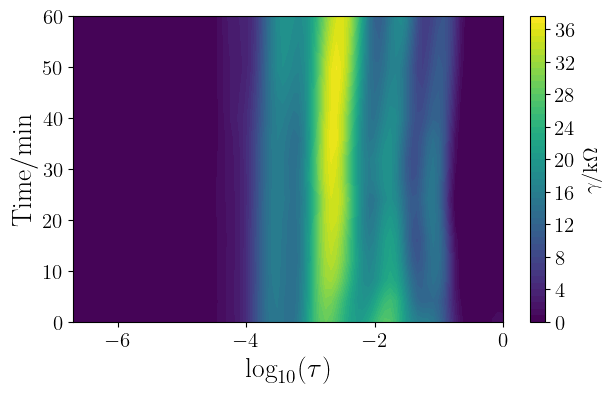

In [25]:
psi_list = [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 50, 60] 

Tau, Psi = np.meshgrid(np.log10(tau_vec), psi_list)
plt.contourf(Tau, Psi, gamma_mat.T/1000, levels=50, cmap='viridis')
plt.colorbar(label=r'$\gamma/\rm k \Omega$')
plt.ylim(0, 60)
plt.xlabel(r'$\log_{10}(\tau)$', fontsize=20)
plt.ylabel(r'$\rm Time/\rm min$', fontsize=20)
plt.tight_layout()
fig = plt.gcf()
fig.set_size_inches(6.472, 4)
plt.show()

## 3.2 Nyquist plots of the experimental and recovered impedances (Figure 8 (b))

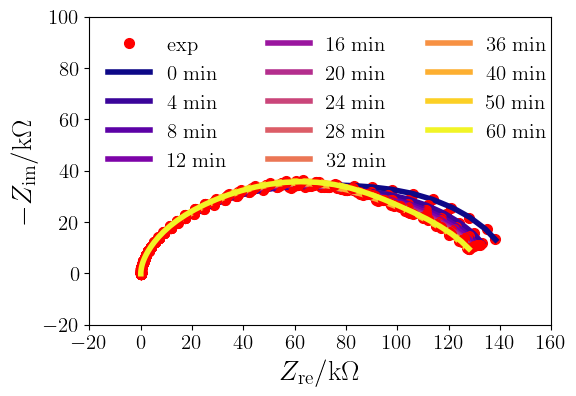

In [26]:
cmap = plt.get_cmap('plasma')

plt.plot(Z_re_list[n]/1000, -Z_im_list[n]/1000, 'o', markersize=7, color='red', label='exp')
for n in range(N_exp):
    plt.plot(Z_re_list[n]/1000, -Z_im_list[n]/1000, 'o', markersize=7, color='red')
    plt.plot(Z_hat_list[n][:N_freqs]/1000, -Z_hat_list[n][N_freqs:]/1000, linewidth=4, label=str(psi_list[n])+r'$\rm \; min$', color=cmap.colors[21*n])

plt.legend(frameon=False, fontsize = 15, loc='upper left', ncol=3)
plt.axis('scaled')
plt.xlim(-20, 160)
plt.ylim(-20, 100)
plt.xticks(range(-20, 161, 20))
plt.yticks(range(-20, 101, 20))
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel(r'$Z_{\rm re}/\rm k \Omega$', fontsize = 20)
plt.ylabel(r'$-Z_{\rm im}/\rm k \Omega$', fontsize = 20)

fig = plt.gcf()
fig.set_size_inches(6.472, 4)
plt.show()